# Paying for Progress? The Causal Effect of Financial Incentives on Female STEM Enrollment

**Mehmet Fatih Çiftaslan** — Università degli Studi di Milano  
📄 [SSRN Working Paper 6282579](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=6282579)

---

## Notebook Structure

| Section | Content |
|---|---|
| 1 | Setup — imports, file paths, shared functions |
| 2 | Data loading & preprocessing |
| 3 | Descriptive statistics (Table 1) |
| 4 | Parallel trends validation |
| 5 | Main DiD regressions (Table 2) |
| 6 | Permutation-based inference |
| 7 | Sub-discipline analysis & impact calculation |
| 8 | Figure 1 — Female share trends |


## 1. Setup

All imports, file paths, and shared helper functions are defined here.  
**Adjust `FILE_INTL` and `FILE_DOM`** if your data files are in a different location.


In [6]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.family':    'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
})

# ── File paths ────────────────────────────────────────────────────────────────
# Place the two MUR CSV files in the ../data/ directory (see README).
FILE_INTL = '/content/11_laureatiinternazionalixclasse.csv'
FILE_DOM  = '/content/05_laureatixclasse.csv'

# ── Constants ─────────────────────────────────────────────────────────────────
MIN_AVG_ENROLLMENT = 30    # Minimum average annual graduates per LM code
START_YEAR         = 2011  # First enrollment year in sample
POLICY_YEAR        = 2022  # First post-treatment enrollment year

# ── LM-code classification (MUR Circular No. 13676, 11 May 2022) ─────────────
ENGINEERING_CODES  = set(range(20, 36)) | {4, 53}
ICT_CODES          = {18, 66, 91}
BASIC_SCI_CODES    = {17, 40, 44, 58, 82, 54, 6, 7, 8, 9, 60, 75}
NON_STEM_SOC_CODES = {
    16, 56, 76, 77, 82, 83, 52, 62, 63, 81, 87, 88, 90,
    1, 2, 5, 10, 11, 14, 15, 36, 37, 38, 39, 43, 45,
    64, 65, 80, 84, 89, 92, 93, 94, 50, 51, 57, 85,
}

def categorize_lm(code: str) -> str:
    """
    Map an LM-code string to one of four discipline categories.

    Returns
    -------
    'ENGINEERING' | 'ICT' | 'BASIC_SCIENCES' | 'NON_STEM_SOC' | 'EXCLUDED'
    """
    try:
        c = str(code).strip()
        if not c.startswith('LM-') or 'CU' in c.split('-'):
            return 'EXCLUDED'
        num = int(re.search(r'\d+', c.split('-')[1]).group())
        if num in ENGINEERING_CODES:  return 'ENGINEERING'
        if num in ICT_CODES:          return 'ICT'
        if num in BASIC_SCI_CODES:    return 'BASIC_SCIENCES'
        if num in NON_STEM_SOC_CODES: return 'NON_STEM_SOC'
    except Exception:
        pass
    return 'EXCLUDED'


def add_stars(p: float) -> str:
    """Return significance stars for a p-value."""
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''


print('Setup complete.')


Setup complete.


## 2. Data Loading & Preprocessing

Both datasets are loaded, filtered to Master's-level programs, and aggregated  
to category × year cells. Enrollment year is imputed as **graduation year − 2**.


In [7]:
def load_and_process(filepath, count_col, sex_col, label):
    """
    Load an MUR graduate CSV, apply sample filters, and return:
      - panel : category x year DataFrame with Share_F outcome
      - raw   : filtered row-level DataFrame (for sub-discipline analysis)
    """
    df = pd.read_csv(filepath, delimiter=';', encoding='latin1')
    df['ClasseNUMERO'] = df['ClasseNUMERO'].astype(str).str.strip().str.upper()

    # Enrollment year = graduation year - 2
    if 'AnnoS' in df.columns:
        df['Year'] = df['AnnoS'].astype(int) - 2
    else:
        df['Year'] = df['AnnoA'].astype(str).str.split('/').str[0].astype(int) - 2

    # Filter: START_YEAR onward, Master's programs only
    df = df[df['Year'] >= START_YEAR].copy()
    df = df[~df['ClasseNUMERO'].str.startswith('L-')].copy()
    df = df[ df['ClasseNUMERO'].str.contains('LM')].copy()

    # Drop small programs
    dept_avg = (
        df.groupby(['ClasseNUMERO', 'Year'])[count_col].sum()
          .reset_index()
          .groupby('ClasseNUMERO')[count_col].mean()
    )
    valid_codes = dept_avg[dept_avg >= MIN_AVG_ENROLLMENT].index.tolist()
    df = df[df['ClasseNUMERO'].isin(valid_codes)].copy()

    # Classify disciplines
    df['Category'] = df['ClasseNUMERO'].apply(categorize_lm)
    df = df[df['Category'] != 'EXCLUDED'].copy()

    # Aggregate to category x year panel
    agg = df.groupby(['Year', 'Category', sex_col])[count_col].sum().reset_index()
    panel = agg.pivot_table(
        index=['Year', 'Category'], columns=sex_col,
        values=count_col, fill_value=0,
    ).reset_index()

    for g in ('F', 'M'):
        if g not in panel.columns:
            panel[g] = 0

    panel['Total']   = panel['F'] + panel['M']
    panel            = panel[panel['Total'] > 0].copy()
    panel['Share_F'] = panel['F'] / panel['Total']
    panel['POST']    = (panel['Year'] >= POLICY_YEAR).astype(int)
    panel['IS_STEM'] = (panel['Category'] != 'NON_STEM_SOC').astype(int)

    print(f'{label}: {len(panel)} category-year cells | '
          f'years {panel["Year"].min()}-{panel["Year"].max()}')
    return panel, df


df_intl, df_intl_raw = load_and_process(FILE_INTL, 'Lau_D', 'SESSO', 'International')
df_dom,  df_dom_raw  = load_and_process(FILE_DOM,  'Lau',   'Sesso', 'Domestic')


International: 48 category-year cells | years 2011-2022
Domestic: 48 category-year cells | years 2011-2022


## 3. Descriptive Statistics — Table 1

Female shares by discipline for 2021 (baseline) and 2022 (post-policy),  
plus a cross-cohort comparison. Reproduces **Table 1** in the paper.


In [8]:
CATS = ['ENGINEERING', 'ICT', 'BASIC_SCIENCES', 'NON_STEM_SOC']
LABELS = {
    'ENGINEERING':   'Engineering',
    'ICT':           'ICT',
    'BASIC_SCIENCES':'Basic Sciences',
    'NON_STEM_SOC':  'Non-STEM Soc (Ref)',
}

def female_share(panel, year, category):
    row = panel[(panel['Year'] == year) & (panel['Category'] == category)]
    if row.empty:
        return 0.0, 0
    return float(row['Share_F'].values[0]), int(row['Total'].values[0])


print('Table 1: Descriptive Statistics\n')

for panel_label, panel in [('A: International Students', df_intl),
                             ('B: Domestic Students',     df_dom)]:
    print(f'Panel {panel_label}')
    print(f'{"":<22} {"2021":>8} {"2022":>8} {"Change":>10} {"N (2021)":>10}')
    print('-' * 60)
    for cat in CATS:
        s21, n21 = female_share(panel, 2021, cat)
        s22, _   = female_share(panel, 2022, cat)
        chg = s22 - s21
        print(f'{LABELS[cat]:<22} {s21:>8.3f} {s22:>8.3f} '
              f'{chg:>+9.3f}   {n21:>10,}')
    print()

print('Panel C: Cross-Cohort Comparison (2021 Baseline)')
print(f'{"":<22} {"International":>14} {"Domestic":>10} {"Difference":>12}')
print('-' * 60)
for cat in CATS:
    si, _ = female_share(df_intl, 2021, cat)
    sd, _ = female_share(df_dom,  2021, cat)
    diff  = si - sd
    print(f'{LABELS[cat]:<22} {si:>14.3f} {sd:>10.3f} {diff:>+11.3f}')


Table 1: Descriptive Statistics

Panel A: International Students
                           2021     2022     Change   N (2021)
------------------------------------------------------------
Engineering               0.353    0.403    +0.049        2,371
ICT                       0.365    0.365    -0.001          312
Basic Sciences            0.545    0.553    +0.008          550
Non-STEM Soc (Ref)        0.665    0.665    +0.000        3,371

Panel B: Domestic Students
                           2021     2022     Change   N (2021)
------------------------------------------------------------
Engineering               0.334    0.341    +0.007       29,501
ICT                       0.228    0.253    +0.026        2,167
Basic Sciences            0.585    0.585    -0.000       12,867
Non-STEM Soc (Ref)        0.700    0.707    +0.006       76,127

Panel C: Cross-Cohort Comparison (2021 Baseline)
                        International   Domestic   Difference
-----------------------------------

## 4. Parallel Trends Validation — Section 4.2

Specification: `Share_F = α + β₁·STEM + β₂·Year + β₃·(STEM × Year) + ε`  
estimated on the **pre-treatment period 2011–2021** only.  
An insignificant β₃ supports the parallel trends assumption.


In [9]:
def parallel_trends_test(panel, label):
    pre = panel[panel['Year'] <= 2021].copy()
    pre['Year_Trend'] = pre['Year'] - START_YEAR

    model = smf.wls(
        'Share_F ~ IS_STEM + Year_Trend + IS_STEM:Year_Trend',
        data=pre, weights=pre['Total'],
    ).fit()

    b3 = model.params['IS_STEM:Year_Trend']
    se = model.bse['IS_STEM:Year_Trend']
    p  = model.pvalues['IS_STEM:Year_Trend']

    print(f'\n── {label} ──')
    print(f'beta3 (STEM x Year) = {b3:.4f}  SE = {se:.4f}  p = {p:.3f}{add_stars(p)}')
    print(f'Cumulative 10-year differential: {b3 * 10 * 100:+.1f} pp')
    if p > 0.10:
        print('Parallel trends supported (p > 0.10)')
    else:
        print('WARNING: pre-trend detected')
    return model


pt_intl = parallel_trends_test(df_intl, 'International (Treatment Group)')
pt_dom  = parallel_trends_test(df_dom,  'Domestic (Placebo Group)')



── International (Treatment Group) ──
beta3 (STEM x Year) = 0.0055  SE = 0.0051  p = 0.289
Cumulative 10-year differential: +5.5 pp
Parallel trends supported (p > 0.10)

── Domestic (Placebo Group) ──
beta3 (STEM x Year) = -0.0016  SE = 0.0076  p = 0.829
Cumulative 10-year differential: -1.6 pp
Parallel trends supported (p > 0.10)


## 5. Main DiD Regressions — Table 2

- **Aggregate model** — single STEM × Post interaction  
- **Heterogeneous model** — separate interactions for Engineering, ICT, Basic Sciences  

Estimated for **international** (treatment) and **domestic** (placebo) cohorts.


In [10]:
def run_did(panel, label):
    print(f'\n{"=" * 60}')
    print(f'  {label}')
    print('=' * 60)

    # Column 1 / 3: Aggregate
    mod_agg = smf.wls(
        'Share_F ~ IS_STEM * POST + C(Year)',
        data=panel, weights=panel['Total'],
    ).fit()
    b = mod_agg.params['IS_STEM:POST']
    s = mod_agg.bse['IS_STEM:POST']
    p = mod_agg.pvalues['IS_STEM:POST']
    print(f'\nAggregate STEM x Post: {b:+.3f}  SE={s:.3f}  p={p:.3f}{add_stars(p)}')
    print(f'R-squared = {mod_agg.rsquared:.3f}')

    # Column 2 / 4: Heterogeneous
    mod_het = smf.wls(
        'Share_F ~ C(Category, Treatment("NON_STEM_SOC")) * POST + C(Year)',
        data=panel, weights=panel['Total'],
    ).fit()

    print('\nHeterogeneous effects (vs Non-STEM Soc reference):')
    for disc in ['ENGINEERING', 'ICT', 'BASIC_SCIENCES']:
        key = f'C(Category, Treatment("NON_STEM_SOC"))[T.{disc}]:POST'
        if key in mod_het.params:
            b = mod_het.params[key]
            s = mod_het.bse[key]
            p = mod_het.pvalues[key]
            print(f'  {disc:<18}: {b:+.3f}  SE={s:.3f}  p={p:.3f}{add_stars(p)}')
    print(f'R-squared = {mod_het.rsquared:.3f}')
    return mod_agg, mod_het


mod_intl_agg, mod_intl_het = run_did(df_intl, 'International Students (Treatment Group)')
mod_dom_agg,  mod_dom_het  = run_did(df_dom,  'Domestic Students (Placebo Group)')



  International Students (Treatment Group)

Aggregate STEM x Post: +0.055  SE=0.039  p=0.172
R-squared = 0.910

Heterogeneous effects (vs Non-STEM Soc reference):
  ENGINEERING       : +0.060  SE=0.017  p=0.001***
  ICT               : +0.030  SE=0.037  p=0.424
  BASIC_SCIENCES    : +0.037  SE=0.029  p=0.201
R-squared = 0.988

  Domestic Students (Placebo Group)

Aggregate STEM x Post: -0.014  SE=0.086  p=0.875
R-squared = 0.781

Heterogeneous effects (vs Non-STEM Soc reference):
  ENGINEERING       : -0.017  SE=0.009  p=0.081*
  ICT               : +0.049  SE=0.029  p=0.102
  BASIC_SCIENCES    : -0.028  SE=0.013  p=0.037**
R-squared = 0.998


## 6. Permutation-Based Inference — Section 4.1

'Engineering' status is randomly reassigned across all LM codes **500 times**.  
The permutation p-value is the fraction of placebo coefficients ≥ the observed effect.


Observed Engineering x Post : +0.0598
Permutation p-value (500 iters): 0.0180**


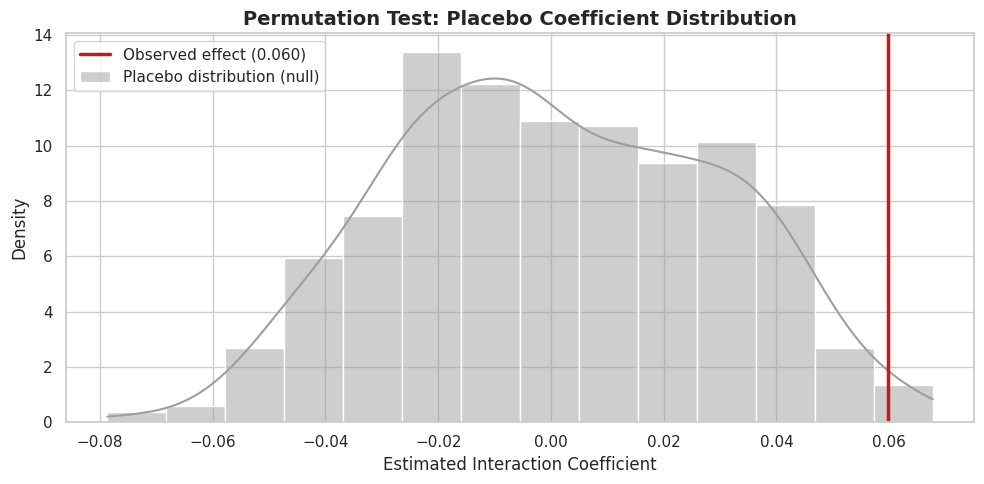

In [11]:
# Build micro-level (LM-code x Year) panel for international cohort
def build_micro_panel(raw_df, count_col, sex_col):
    agg = raw_df.groupby(
        ['Year', 'ClasseNUMERO', 'Category', sex_col]
    )[count_col].sum().reset_index()
    piv = agg.pivot_table(
        index=['Year', 'ClasseNUMERO', 'Category'],
        columns=sex_col, values=count_col, fill_value=0,
    ).reset_index()
    for g in ('F', 'M'):
        if g not in piv.columns: piv[g] = 0
    piv['Total']   = piv['F'] + piv['M']
    piv            = piv[piv['Total'] > 0].copy()
    piv['Share_F'] = piv['F'] / piv['Total']
    piv['POST']    = (piv['Year'] >= POLICY_YEAR).astype(int)
    return piv


micro = build_micro_panel(df_intl_raw, 'Lau_D', 'SESSO')
micro = micro[micro['Category'].isin(['ENGINEERING', 'NON_STEM_SOC'])].copy()
micro['IS_TREATED'] = (micro['Category'] == 'ENGINEERING').astype(int)

obs_model = smf.wls('Share_F ~ IS_TREATED * POST + C(Year)',
                    data=micro, weights=micro['Total']).fit()
obs_beta  = obs_model.params['IS_TREATED:POST']

# Permutation loop
N_PERM     = 500
all_codes  = micro['ClasseNUMERO'].unique()
n_treated  = micro[micro['Category'] == 'ENGINEERING']['ClasseNUMERO'].nunique()
perm_betas = []

np.random.seed(42)
for i in range(N_PERM):
    fake = np.random.choice(all_codes, n_treated, replace=False)
    tmp  = micro.copy()
    tmp['IS_TREATED'] = tmp['ClasseNUMERO'].isin(fake).astype(int)
    try:
        m = smf.wls('Share_F ~ IS_TREATED * POST + C(Year)',
                    data=tmp, weights=tmp['Total']).fit()
        perm_betas.append(m.params['IS_TREATED:POST'])
    except Exception:
        continue

perm_betas = np.array(perm_betas)
perm_pval  = np.mean(np.abs(perm_betas) >= np.abs(obs_beta))

print(f'Observed Engineering x Post : {obs_beta:+.4f}')
print(f'Permutation p-value ({N_PERM} iters): {perm_pval:.4f}{add_stars(perm_pval)}')

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(perm_betas, kde=True, stat='density', color='#9E9E9E',
             label='Placebo distribution (null)', ax=ax)
ax.axvline(obs_beta, color='#B22222', linewidth=2.5,
           label=f'Observed effect ({obs_beta:.3f})')
ax.set_title('Permutation Test: Placebo Coefficient Distribution', fontweight='bold')
ax.set_xlabel('Estimated Interaction Coefficient')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Sub-Discipline Analysis & Impact Calculation — Section 4.4 & 4.5

Discipline-specific DiD coefficients and counterfactual female graduate counts  
for the 2022–2024 post-policy period.


In [12]:
mod_disc = smf.wls(
    'Share_F ~ C(Category, Treatment("NON_STEM_SOC")) * POST + C(Year)',
    data=df_intl, weights=df_intl['Total'],
).fit()

did_coefs = {}
for disc in ['ENGINEERING', 'ICT', 'BASIC_SCIENCES']:
    key = f'C(Category, Treatment("NON_STEM_SOC"))[T.{disc}]:POST'
    if key in mod_disc.params:
        did_coefs[disc] = {
            'beta': mod_disc.params[key],
            'se':   mod_disc.bse[key],
            'pval': mod_disc.pvalues[key],
        }

print('DiD Coefficients by Discipline:\n')
for d, v in did_coefs.items():
    print(f'  {d:<18}: beta={v["beta"]:+.3f}  SE={v["se"]:.3f}  '
          f'p={v["pval"]:.3f}{add_stars(v["pval"])}')

# Counterfactual impact
print('\nCounterfactual Impact: Additional Female Graduates (2022-2024)\n')
print(f'  {"Discipline":<20} {"Total":>10} {"Actual F":>10} '
      f'{"CF (No Policy)":>15} {"Net Gain":>10} {"% Gain":>8}')
print('  ' + '-' * 73)

total_extra = 0
for disc, v in did_coefs.items():
    post = df_intl_raw[
        (df_intl_raw['Year'] >= POLICY_YEAR) &
        (df_intl_raw['ClasseNUMERO'].apply(categorize_lm) == disc)
    ]
    total_g  = post['Lau_D'].sum()
    actual_f = post[post['SESSO'] == 'F']['Lau_D'].sum()
    if total_g == 0:
        continue
    cf_f   = total_g * (actual_f / total_g - v['beta'])
    extra  = actual_f - cf_f
    pct    = extra / cf_f * 100 if cf_f > 0 else 0
    total_extra += extra
    print(f'  {disc:<20} {total_g:>10} {actual_f:>10} '
          f'{int(cf_f):>15} {int(extra):>+10} {pct:>7.1f}%')

print('  ' + '-' * 73)
print(f'  {"TOTAL":<20} {"":>10} {"":>10} {"":>15} {int(total_extra):>+10}')


DiD Coefficients by Discipline:

  ENGINEERING       : beta=+0.060  SE=0.017  p=0.001***
  ICT               : beta=+0.030  SE=0.037  p=0.424
  BASIC_SCIENCES    : beta=+0.037  SE=0.029  p=0.201

Counterfactual Impact: Additional Female Graduates (2022-2024)

  Discipline                Total   Actual F  CF (No Policy)   Net Gain   % Gain
  -------------------------------------------------------------------------
  ENGINEERING                3494       1407            1197       +209    17.5%
  ICT                         417        152             139        +12     9.0%
  BASIC_SCIENCES              777        430             400        +29     7.2%
  -------------------------------------------------------------------------
  TOTAL                                                            +251


## 8. Figure 1 — Female Share Trends by Discipline (2011–2024)

International (treatment) and domestic (placebo) panels side by side,  
with a vertical dashed line at policy implementation (2022).


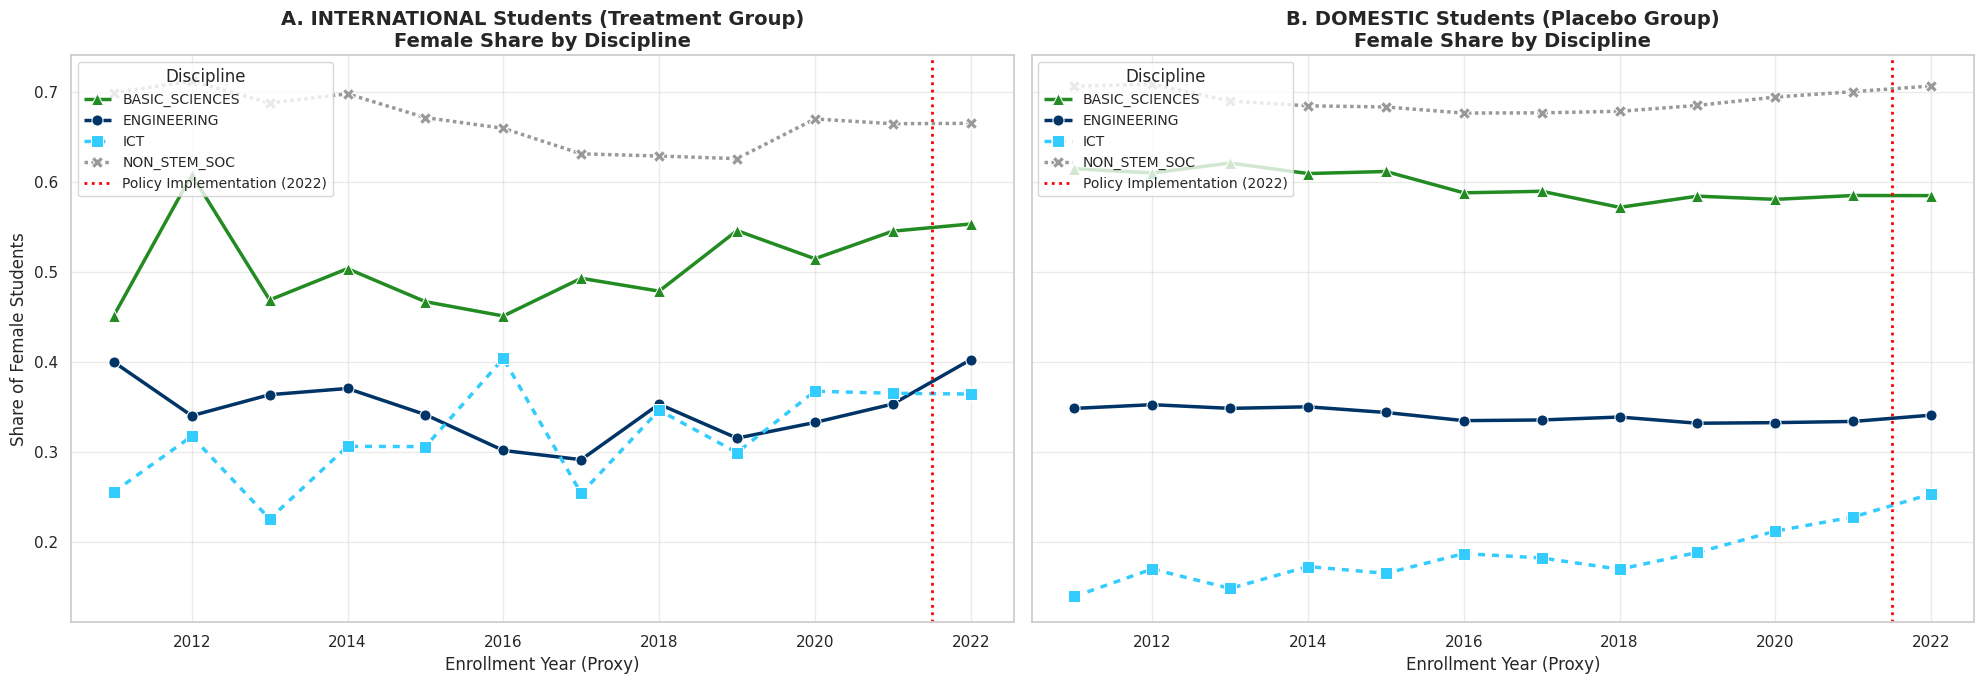

Figure 1 saved as Figure1_Trends.png


In [13]:
PALETTE = {
    'ENGINEERING':    '#003366',
    'ICT':            '#33CCFF',
    'BASIC_SCIENCES': '#228B22',
    'NON_STEM_SOC':   '#999999',
}
MARKERS = {'ENGINEERING': 'o', 'ICT': 's', 'BASIC_SCIENCES': '^', 'NON_STEM_SOC': 'X'}
DASHES  = {'ENGINEERING': (1,0), 'ICT': (2,2), 'BASIC_SCIENCES': (1,0), 'NON_STEM_SOC': (1,1)}

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

panel_configs = [
    (df_intl, 'A. INTERNATIONAL Students (Treatment Group)'),
    (df_dom,  'B. DOMESTIC Students (Placebo Group)'),
]

for ax, (panel, title_prefix) in zip(axes, panel_configs):
    sns.lineplot(
        data=panel, x='Year', y='Share_F', hue='Category', style='Category',
        palette=PALETTE, markers=MARKERS, dashes=DASHES,
        linewidth=2.5, markersize=8, ax=ax,
    )
    ax.axvline(POLICY_YEAR - 0.5, color='red', linestyle=':', linewidth=2,
               label=f'Policy Implementation ({POLICY_YEAR})')
    ax.set_title(f'{title_prefix}\nFemale Share by Discipline', fontweight='bold')
    ax.set_xlabel('Enrollment Year (Proxy)')
    ax.set_ylabel('Share of Female Students' if ax is axes[0] else '')
    ax.legend(title='Discipline', loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('Figure1_Trends.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved as Figure1_Trends.png')
